In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [2]:
data_dir = Path("../data/raw")

X = pd.read_csv(
    data_dir / "secom.data",
    sep=r"\s+",
    header=None,
    na_values="NaN"
)

y = pd.read_csv(
    data_dir / "secom_labels.data",
    sep=r"\s+",
    header=None
)

missing_ratio = X.isna().mean()
high_missing_features = missing_ratio[missing_ratio >= 0.5].index

X_reduced = X.drop(columns=high_missing_features)
X_clean = X_reduced.fillna(X_reduced.median())

feature_variance = X_clean.var()
zero_variance_features = feature_variance[feature_variance == 0].index

X_clean = X_clean.drop(columns=zero_variance_features)

scaler = StandardScaler()

X_scaled_array = scaler.fit_transform(X_clean)

X_scaled = pd.DataFrame(
    X_scaled_array,
    columns=X_clean.columns,
    index=X_clean.index
)

print("X_clean shape:", X_clean.shape)
print("X_scaled shape:", X_scaled.shape)
print("y shape:", y.shape)

X_clean shape: (1567, 446)
X_scaled shape: (1567, 446)
y shape: (1567, 2)


In [3]:
pca = PCA(n_components=0.90, random_state=42)

X_pca = pca.fit_transform(X_scaled)
X_reconstructed = pca.inverse_transform(X_pca)

print("Original scaled shape:", X_scaled.shape)
print("PCA compressed shape:", X_pca.shape)
print("Reconstructed shape:", X_reconstructed.shape)

print("선택된 PCA component 수:", pca.n_components_)
print("누적 설명 분산 비율:", pca.explained_variance_ratio_.sum())

Original scaled shape: (1567, 446)
PCA compressed shape: (1567, 129)
Reconstructed shape: (1567, 446)
선택된 PCA component 수: 129
누적 설명 분산 비율: 0.900369432833241


/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/decomposition/_base.py:197: RuntimeWarning: divide by zero encountered in matmul
  return X @ self.components_ + self.mean_
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/decomposition/_base.py:197: RuntimeWarning: overflow encountered in matmul
  return X @ self.components_ + self.mean_
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/decomposition/_base.py:197: RuntimeWarning: invalid value encountered in matmul
  return X @ self.components_ + self.mean_


In [4]:
import numpy as np

print("X_scaled에 NaN 개수:", np.isnan(X_scaled_array).sum())
print("X_scaled에 inf 개수:", np.isinf(X_scaled_array).sum())

print("X_reconstructed에 NaN 개수:", np.isnan(X_reconstructed).sum())
print("X_reconstructed에 inf 개수:", np.isinf(X_reconstructed).sum())

X_scaled에 NaN 개수: 0
X_scaled에 inf 개수: 0
X_reconstructed에 NaN 개수: 0
X_reconstructed에 inf 개수: 0


In [5]:
reconstruction_error = ((X_scaled_array - X_reconstructed) ** 2).mean(axis=1)

pca_result = pd.DataFrame({
    "label": y[0],
    "timestamp": y[1],
    "reconstruction_error": reconstruction_error,
})

print("Reconstruction error 요약:")
print(pca_result["reconstruction_error"].describe())

print("\nPass 평균 reconstruction error:")
print(pca_result.loc[pca_result["label"] == -1, "reconstruction_error"].mean())

print("\nFail 평균 reconstruction error:")
print(pca_result.loc[pca_result["label"] == 1, "reconstruction_error"].mean())

Reconstruction error 요약:
count    1567.000000
mean        0.099631
std         0.056822
min         0.003851
25%         0.075570
50%         0.086533
75%         0.103792
max         0.935663
Name: reconstruction_error, dtype: float64

Pass 평균 reconstruction error:
0.09878692575056168

Fail 평균 reconstruction error:
0.11149833055038082


In [6]:
pca_alert_ratios = [0.05, 0.10, 0.15]

pca_threshold_results = []

total_fail = (pca_result["label"] == 1).sum()
total_pass = (pca_result["label"] == -1).sum()

for ratio in pca_alert_ratios:
    cutoff = pca_result["reconstruction_error"].quantile(1 - ratio)

    predicted_alert = pca_result["reconstruction_error"] >= cutoff

    total_alerts = predicted_alert.sum()
    fail_alerts = ((pca_result["label"] == 1) & predicted_alert).sum()
    pass_alerts = ((pca_result["label"] == -1) & predicted_alert).sum()

    fail_capture_rate = fail_alerts / total_fail
    false_alert_rate = pass_alerts / total_pass
    alert_fail_ratio = fail_alerts / total_alerts if total_alerts > 0 else 0

    pca_threshold_results.append({
        "alert_ratio": ratio,
        "error_cutoff": cutoff,
        "total_alerts": total_alerts,
        "fail_alerts": fail_alerts,
        "pass_alerts": pass_alerts,
        "fail_capture_rate": fail_capture_rate,
        "false_alert_rate": false_alert_rate,
        "alert_fail_ratio": alert_fail_ratio,
    })

pca_threshold_df = pd.DataFrame(pca_threshold_results)

print(pca_threshold_df)

   alert_ratio  error_cutoff  total_alerts  fail_alerts  pass_alerts  \
0         0.05      0.176985            79           10           69   
1         0.10      0.136487           157           18          139   
2         0.15      0.119386           235           25          210   

   fail_capture_rate  false_alert_rate  alert_fail_ratio  
0           0.096154          0.047163          0.126582  
1           0.173077          0.095010          0.114650  
2           0.240385          0.143541          0.106383  


In [7]:
model_comparison_df = pd.DataFrame([
    {
        "method": "SPC baseline",
        "threshold": "alert_count >= 1",
        "total_alerts": 92,
        "fail_alerts": 19,
        "pass_alerts": 73,
        "fail_capture_rate": 0.182692,
        "false_alert_rate": 0.049897,
        "alert_fail_ratio": 0.206522,
    },
    {
        "method": "Isolation Forest",
        "threshold": "score bottom 5%",
        "total_alerts": 79,
        "fail_alerts": 11,
        "pass_alerts": 68,
        "fail_capture_rate": 0.105769,
        "false_alert_rate": 0.046480,
        "alert_fail_ratio": 0.139241,
    },
    {
        "method": "PCA reconstruction",
        "threshold": "error top 5%",
        "total_alerts": 79,
        "fail_alerts": 10,
        "pass_alerts": 69,
        "fail_capture_rate": 0.096154,
        "false_alert_rate": 0.047163,
        "alert_fail_ratio": 0.126582,
    },
])

print(model_comparison_df)

               method         threshold  total_alerts  fail_alerts  \
0        SPC baseline  alert_count >= 1            92           19   
1    Isolation Forest   score bottom 5%            79           11   
2  PCA reconstruction      error top 5%            79           10   

   pass_alerts  fail_capture_rate  false_alert_rate  alert_fail_ratio  
0           73           0.182692          0.049897          0.206522  
1           68           0.105769          0.046480          0.139241  
2           69           0.096154          0.047163          0.126582  


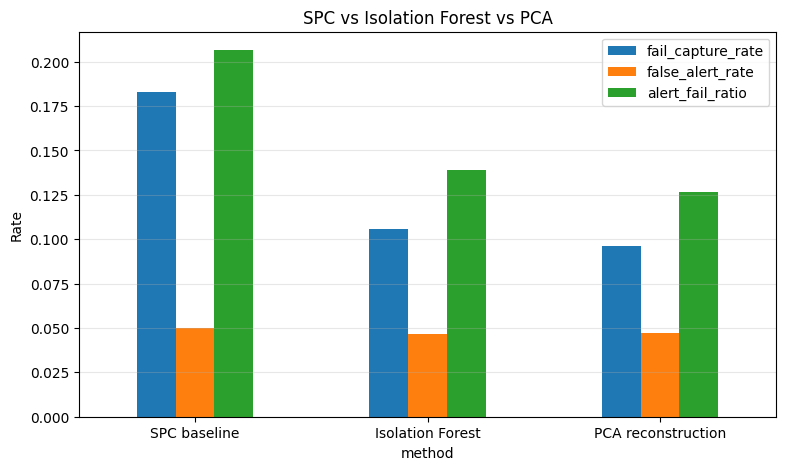

In [8]:
metrics = ["fail_capture_rate", "false_alert_rate", "alert_fail_ratio"]

model_plot_df = model_comparison_df.set_index("method")[metrics]

model_plot_df.plot(
    kind="bar",
    figsize=(9, 5),
)

plt.title("SPC vs Isolation Forest vs PCA")
plt.ylabel("Rate")
plt.xticks(rotation=0)
plt.legend(loc="upper right")
plt.grid(axis="y", alpha=0.3)
plt.show()

## PCA Reconstruction Error Anomaly Detection Summary

This notebook applied PCA reconstruction error for anomaly detection on the preprocessed SECOM dataset.

### PCA Concept

PCA, or Principal Component Analysis, is a dimensionality reduction method.

In this analysis, PCA was used to compress the standardized SECOM feature data into a lower-dimensional representation and then reconstruct it back to the original feature space.

Samples that were not well reconstructed were considered potential anomalies.

### Data Preparation

The same preprocessing steps were used:

1. Remove features with missing ratio greater than or equal to 50%
2. Fill remaining missing values with each feature's median
3. Remove zero-variance features
4. Standardize features using `StandardScaler`

The final data shape was:

- `X_clean`: 1,567 × 446
- `X_scaled`: 1,567 × 446
- `y`: 1,567 × 2

### PCA Setup

PCA was configured to explain 90% of the variance.

Result:

- Original feature dimension: 446
- Selected PCA components: 129
- Explained variance ratio: 90.04%

### Reconstruction Error

After PCA compression and reconstruction, reconstruction error was calculated using sample-wise mean squared error.

Pass and fail average reconstruction errors were:

| Group | Mean Reconstruction Error |
|---|---:|
| Pass | 0.0988 |
| Fail | 0.1115 |

Fail samples had a slightly higher average reconstruction error than pass samples, suggesting that fail samples were somewhat less consistent with the main PCA patterns.

### Threshold Comparison

Samples with the highest reconstruction error were treated as anomaly candidates.

| Alert Ratio | Total Alerts | Fail Alerts | Pass Alerts | Fail Capture Rate | False Alert Rate | Alert Fail Ratio |
|---:|---:|---:|---:|---:|---:|---:|
| 5% | 79 | 10 | 69 | 9.62% | 4.72% | 12.66% |
| 10% | 157 | 18 | 139 | 17.31% | 9.50% | 11.46% |
| 15% | 235 | 25 | 210 | 24.04% | 14.35% | 10.64% |

As the alert ratio increased, PCA captured more fail samples but also produced more false alerts.

The alert fail ratio decreased as the alert group became larger.

### Comparison with SPC and Isolation Forest

For fair comparison, the 5% PCA threshold was compared with SPC baseline and Isolation Forest because all three methods had a similar false alert rate near 5%.

| Method | Threshold | Total Alerts | Fail Alerts | Pass Alerts | Fail Capture Rate | False Alert Rate | Alert Fail Ratio |
|---|---|---:|---:|---:|---:|---:|---:|
| SPC baseline | alert count >= 1 | 92 | 19 | 73 | 18.27% | 4.99% | 20.65% |
| Isolation Forest | score bottom 5% | 79 | 11 | 68 | 10.58% | 4.65% | 13.92% |
| PCA reconstruction | error top 5% | 79 | 10 | 69 | 9.62% | 4.72% | 12.66% |

### Interpretation

Under similar false alert rates, SPC baseline captured more fail samples and had a higher alert fail ratio than both Isolation Forest and PCA reconstruction error.

The current ranking was:

1. SPC baseline
2. Isolation Forest
3. PCA reconstruction error

However, this result only reflects the current settings.

PCA was tested with 90% explained variance and top 5% reconstruction error threshold. Different PCA component settings or thresholds may produce different results.

### Conclusion

PCA reconstruction error identified samples with a higher fail ratio than the overall dataset, but it did not outperform the SPC baseline under the current settings.

The result suggests that PCA can be used as an additional anomaly detection candidate, but SPC remained the strongest baseline in this experiment.